In [1]:
!pip install torch torchvision Pillow matplotlib

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("awsaf49/coco-2017-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'coco-2017-dataset' dataset.
Path to dataset files: /kaggle/input/coco-2017-dataset


In [3]:
import torch
import torchvision
from PIL import Image
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
CUDA available: True


In [4]:
COCO_LABELS = [
    '__background__', 'person', 'bicycle', 'car',
    'motorcycle', 'airplane', 'bus', 'train', 'truck',
    'boat', 'traffic light', 'fire hydrant', 'N/A',
    'stop sign', 'parking meter', 'bench', 'bird',
    'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant',
    'bear', 'zebra', 'giraffe', 'N/A', 'backpack',
    'umbrella', 'N/A', 'N/A', 'handbag', 'tie',
    'suitcase', 'frisbee', 'skis', 'snowboard',
    'sports ball', 'kite', 'baseball bat',
    'baseball glove', 'skateboard', 'surfboard',
    'tennis racket', 'bottle', 'N/A', 'wine glass',
    'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana',
    'apple', 'sandwich', 'orange', 'broccoli', 'carrot',
    'hot dog', 'pizza', 'donut', 'cake', 'chair',
    'couch', 'potted plant', 'bed', 'N/A',
    'dining table', 'N/A', 'N/A', 'toilet', 'N/A',
    'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster',
    'sink', 'refrigerator', 'N/A', 'book', 'clock',
    'vase', 'scissors', 'teddy bear', 'hair drier',
    'toothbrush'
]

In [5]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights

# Load model with the best available weights
weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn_v2(weights=weights)

# Set to evaluation mode (important!)
model.eval()
print("Model loaded successfully!")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 183MB/s]


Model loaded successfully!


In [6]:
from torchvision import transforms

# 1. Update this path to point to an actual image in your Kaggle dataset!
image_path = "/kaggle/input/coco-2017-dataset/coco2017/val2017/000000039769.jpg"

image = Image.open(image_path).convert("RGB")

# Convert image to tensor (scales pixels to 0-1)
transform = transforms.ToTensor()
image_tensor = transform(image)

print(f"Image size: {image.size}")
print(f"Tensor shape: {image_tensor.shape}")

Image size: (640, 480)
Tensor shape: torch.Size([3, 480, 640])


In [7]:
# Run detection (no gradient needed for inference)
with torch.no_grad():
    predictions = model([image_tensor])

# The model returns a list; get first image's results
pred = predictions[0]

print(f"Detected {len(pred['boxes'])} objects")
print(f"Keys: {pred.keys()}")

Detected 10 objects
Keys: dict_keys(['boxes', 'labels', 'scores'])


In [8]:
# Set confidence threshold
THRESHOLD = 0.5

# Filter predictions
boxes = pred['boxes'][pred['scores'] > THRESHOLD]
labels = pred['labels'][pred['scores'] > THRESHOLD]
scores = pred['scores'][pred['scores'] > THRESHOLD]

# Print results
print(f"\nObjects detected (confidence > {THRESHOLD}):\n")
for i in range(len(boxes)):
    label_name = COCO_LABELS[labels[i]]
    confidence = scores[i].item() * 100
    box = boxes[i].tolist()
    print(f"{label_name}: {confidence:.1f}%")
    print(f"Location: ({box[0]:.0f}, {box[1]:.0f}) to ({box[2]:.0f}, {box[3]:.0f})")


Objects detected (confidence > 0.5):

cat: 99.9%
Location: (339, 18) to (640, 364)
cat: 99.9%
Location: (16, 50) to (324, 466)
remote: 97.6%
Location: (37, 74) to (176, 120)
couch: 86.9%
Location: (6, 0) to (640, 468)
remote: 72.7%
Location: (333, 77) to (370, 187)


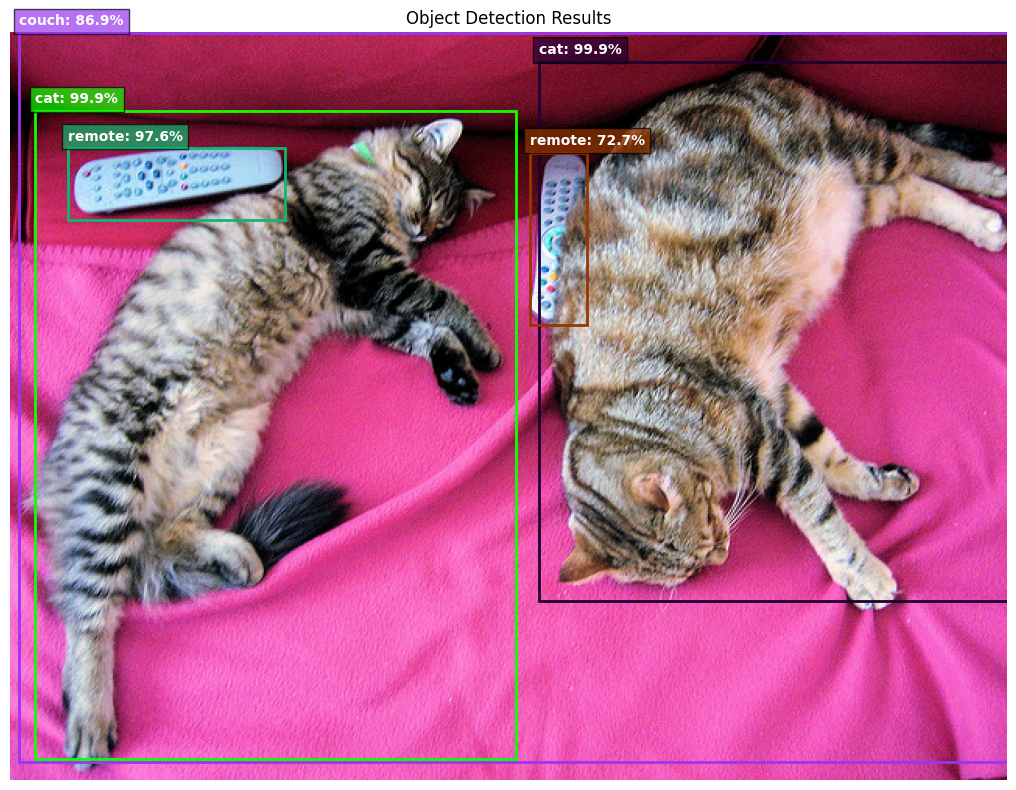

Result saved as detection_result.jpg


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

def visualize_detections(image, boxes, labels, scores, threshold=0.5):
    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(image)

    for i in range(len(boxes)):
        box = boxes[i].tolist()
        label = COCO_LABELS[labels[i]]
        score = scores[i].item()

        # Random color for each box
        color = [random.random() for _ in range(3)]

        # Draw bounding box
        x1, y1, x2, y2 = box
        width = x2 - x1
        height = y2 - y1
        rect = patches.Rectangle((x1, y1), width, height, linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)

        # Add label text
        ax.text(x1, y1 - 5, f"{label}: {score:.1%}", color='white', fontsize=10, fontweight='bold', bbox=dict(facecolor=color, alpha=0.7))

    ax.axis('off')
    plt.title('Object Detection Results')
    plt.tight_layout()
    plt.savefig('detection_result.jpg', dpi=150)
    plt.show()
    print("Result saved as detection_result.jpg")

# Call the function
visualize_detections(image, boxes, labels, scores)

In [10]:
def count_objects(labels, target_label_name):
    # Find the numeric ID for our target (e.g., 'person')
    target_id = COCO_LABELS.index(target_label_name)

    # Count how many times that ID appears in our filtered labels
    count = (labels == target_id).sum().item()
    return count

person_count = count_objects(labels, 'person')
car_count = count_objects(labels, 'car')

print(f"Found {person_count} people and {car_count} cars in this image.")

Found 0 people and 0 cars in this image.


In [11]:
import os

# Update the folder path to the Kaggle dataset directory
image_folder = "/kaggle/input/coco-2017-dataset/coco2017/val2017/"

# Add a small limit (like 5 images) so Kaggle doesn't crash trying to process all 5,000!
for i, filename in enumerate(os.listdir(image_folder)):
    if i >= 5:
        break

    if filename.endswith(".jpg") or filename.endswith(".png"):
        img_path = os.path.join(image_folder, filename)
        img = Image.open(img_path).convert("RGB")
        img_tensor = transform(img)

        with torch.no_grad():
            preds = model([img_tensor])[0]

        # Filter (keeping threshold at 0.5)
        keep = preds['scores'] > 0.5
        b = preds['boxes'][keep]
        l = preds['labels'][keep]
        s = preds['scores'][keep]

        print(f"Processed {filename}: Found {len(b)} objects.")

Processed 000000011197.jpg: Found 19 objects.
Processed 000000219485.jpg: Found 1 objects.
Processed 000000151000.jpg: Found 15 objects.
Processed 000000371677.jpg: Found 13 objects.
Processed 000000038825.jpg: Found 2 objects.


In [12]:
from torchvision.models.detection import ssd300_vgg16, SSD300_VGG16_Weights

# Load the SSD model instead of Faster R-CNN
ssd_weights = SSD300_VGG16_Weights.DEFAULT
ssd_model = ssd300_vgg16(weights=ssd_weights)
ssd_model.eval()

# Run it exactly the same way!
with torch.no_grad():
    ssd_predictions = ssd_model([image_tensor])[0]

print("Successfully ran SSD model!")

Downloading: "https://download.pytorch.org/models/ssd300_vgg16_coco-b556d3b4.pth" to /root/.cache/torch/hub/checkpoints/ssd300_vgg16_coco-b556d3b4.pth


100%|██████████| 136M/136M [00:00<00:00, 190MB/s]


Successfully ran SSD model!
